The importance of a  recursive forecast consists on the model using its own predictions to predict further more into the future

Recursive Forecast Results
MAE:  11565.62
RMSE: 14325.01


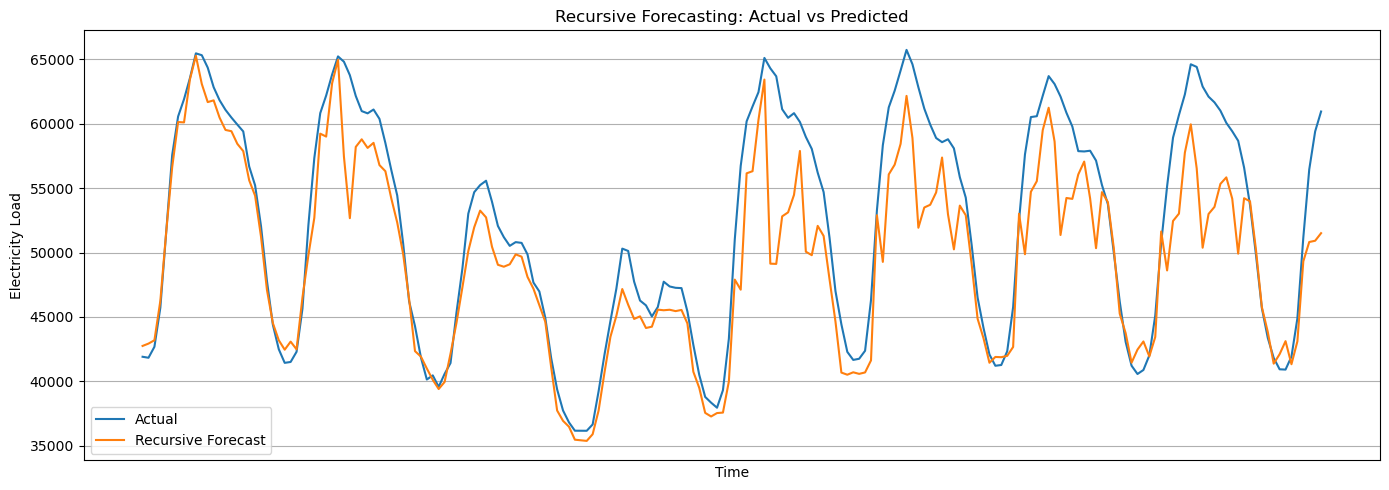

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
df= pd.read_csv('/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv')
# =========================================================
# 1. PREPARE DATA
# =========================================================
df.index = pd.to_datetime(df.index)

target_col = "DE_load_actual_entsoe_transparency"

series = df[target_col].dropna().copy()

# =========================================================
# 2. TRAIN / TEST SPLIT
# =========================================================
split_idx = int(len(series) * 0.8)

train_series = series.iloc[:split_idx].copy()
test_series = series.iloc[split_idx:].copy()

# =========================================================
# 3. CREATE LAG FEATURES FOR TRAINING
# =========================================================
def create_lag_features(series, lags):
    X = []
    y = []
    
    values = series.values
    
    max_lag = max(lags)
    
    for i in range(max_lag, len(values)):
        row = [values[i - lag] for lag in lags]
        X.append(row)
        y.append(values[i])
    
    return np.array(X), np.array(y)

lags = [6, 24, 72, 168]

X_train, y_train = create_lag_features(train_series, lags)

# =========================================================
# 4. TRAIN MODEL
# =========================================================
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 5. RECURSIVE FORECAST
# =========================================================
history = list(train_series.values)
recursive_preds = []

for _ in range(len(test_series)):
    x_input = np.array([[history[-lag] for lag in lags]])
    pred = model.predict(x_input)[0]
    recursive_preds.append(pred)
    history.append(pred)

recursive_preds = np.array(recursive_preds)

# =========================================================
# 6. EVALUATE
# =========================================================
y_true = test_series.values

mae = mean_absolute_error(y_true, recursive_preds)
rmse = np.sqrt(mean_squared_error(y_true, recursive_preds))

print("Recursive Forecast Results")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# =========================================================
# 7. PLOT: ACTUAL VS RECURSIVE PREDICTION
# =========================================================
n = 200

plt.figure(figsize=(14, 5))
plt.plot(test_series.index[:n], y_true[:n], label="Actual")
plt.plot(test_series.index[:n], recursive_preds[:n], label="Recursive Forecast")

plt.title("Recursive Forecasting: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Electricity Load")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The recursive forecasting results show that the model is able to capture the overall trend and seasonal patterns in electricity demand. However, prediction accuracy decreases over time due to error accumulation, as each predicted value is used as input for subsequent predictions. This leads to increasing deviation from the actual values, particularly during peak periods